# Task 1 — Historical PM2.5 Data and Trend Attributes (Initial Approach) Veena
**Feature Category 1 from literature review**

This notebook engineers historical PM2.5 features for **London Marylebone Road** covering 2016–2025.

Features produced:
- **Raw lag features** — PM2.5 values from previous 1, 7, 14 and 30 days
- **Rolling averages** — 3, 7, 14 and 30 day rolling means
- **Rolling statistics** — standard deviation, min, max
- **Rate of change** — day-on-day difference, 7-day difference, percentage change
- **Seasonal components** — trend and seasonality extracted via decomposition

**Files needed:**
- `AirQualityDataDaily2016_2020.csv` — upload to `/content/`
- `AirQualityDataDaily2021_2025.csv` — upload to `/content/`

---

## 1.1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

print('All imports done!')

All imports done!


## 1.2. Load and Merge PM2.5 Data
Load both CSV files and combine into one continuous daily series for London Marylebone Road.

In [2]:
def load_defra_single_station(filepath):
    """
    Load a DEFRA daily CSV for a single station.
    Skips 11 metadata rows, returns clean date + pm25 dataframe.
    """
    raw = pd.read_csv(filepath, skiprows=11, header=None,
                      usecols=[0, 1], names=['date', 'pm25'])
    # Drop non-date rows (e.g. blank rows, End row at bottom)
    raw = raw[raw['date'].astype(str).str.match(r'\d{4}|\d{2}/\d{2}/\d{4}', na=False)]
    raw['date'] = pd.to_datetime(raw['date'], dayfirst=True, errors='coerce').dt.normalize()
    raw['pm25'] = pd.to_numeric(raw['pm25'], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw

# Load only the 2021-2025 file
df = load_defra_single_station('/content/PM2.5_AirQualityDataDaily_2021-2025.csv')

# Sort and drop duplicates
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)

# Add station name
df['station'] = 'London Marylebone Road'

print(f'Combined shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Missing PM2.5 values: {df["pm25"].isna().sum()}')
df.head(10)

Combined shape: (720, 3)
Date range: 2021-01-01 to 2025-12-12
Missing PM2.5 values: 33


,date,pm25,station
0,2021-01-01,17.167,London Marylebone Road
1,2021-01-02,13.724,London Marylebone Road
2,2021-01-03,26.917,London Marylebone Road
3,2021-01-04,17.167,London Marylebone Road
4,2021-01-05,10.000,London Marylebone Road
5,2021-01-06,12.385,London Marylebone Road
6,2021-01-07,7.720,London Marylebone Road
7,2021-01-08,4.333,London Marylebone Road
8,2021-01-09,6.417,London Marylebone Road
9,2021-01-10,6.083,London Marylebone Road


## 1.3. Basic Cleaning
Remove impossible values and fill the time index so it is fully continuous.

Negative values removed: 0
Missing values after reindex: 1120 (62.0%)
Total days in series: 1807


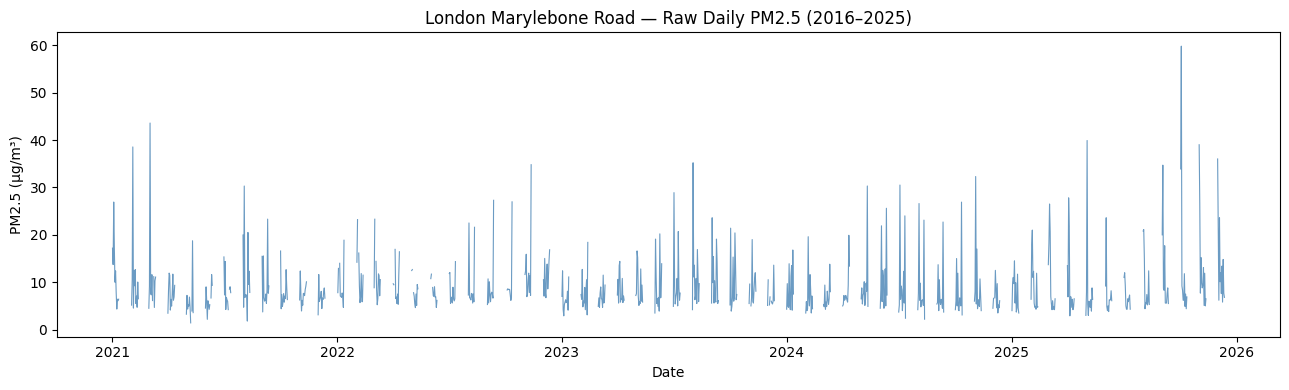

Saved: pm25_raw_series.png


In [3]:
# Drop negative values — physically impossible for PM2.5
negatives = (df['pm25'] < 0).sum()
df = df[~(df['pm25'] < 0)].copy()
print(f'Negative values removed: {negatives}')

# Reindex to a complete daily date range so gaps are visible
full_idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
df = df.set_index('date').reindex(full_idx).rename_axis('date').reset_index()
df['station'] = 'London Marylebone Road'

missing_after = df['pm25'].isna().sum()
print(f'Missing values after reindex: {missing_after} ({missing_after/len(df)*100:.1f}%)')
print(f'Total days in series: {len(df)}')

# Plot raw time series
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['date'], df['pm25'], linewidth=0.8, color='steelblue', alpha=0.8)
ax.set_title('London Marylebone Road — Raw Daily PM2.5 (2016–2025)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('pm25_raw_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_raw_series.png')

## 1.4. Fill Missing Values
Use linear interpolation for short gaps (1-3 days) and forward/backward fill for any remaining gaps.

In [ ]:
# Record which values were originally observed vs filled
df['was_observed'] = df['pm25'].notna()

# Linear interpolation — limit to 3 consecutive days
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3, limit_area='inside')

# Forward fill then backward fill for any remaining gaps at edges
df['pm25'] = df['pm25'].ffill().bfill()

df['pm25_imputed'] = ~df['was_observed']

print(f'Values after interpolation: {df["pm25"].notna().sum()}')
print(f'Still missing: {df["pm25"].isna().sum()}')
print(f'Imputed rows: {df["pm25_imputed"].sum()}')
df.head()

Values after interpolation: 1807
Still missing: 0
Imputed rows: 1120


,date,pm25,station,was_observed,pm25_imputed
0,2021-01-01,17.167,London Marylebone Road,True,False
1,2021-01-02,13.724,London Marylebone Road,True,False
2,2021-01-03,26.917,London Marylebone Road,True,False
3,2021-01-04,17.167,London Marylebone Road,True,False
4,2021-01-05,10.000,London Marylebone Road,True,False


## 1.5. Raw Lag Features
Past PM2.5 values as direct inputs — what the model saw on previous days.

In [ ]:
# Lag features — PM2.5 value from N days ago
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'pm25_lag_{lag}d'] = df['pm25'].shift(lag)

lag_features = [f'pm25_lag_{lag}d' for lag in [1, 2, 3, 7, 14, 30]]

print(f'Lag features added: {lag_features}')
print()
print('Sample (first 10 rows):')
print(df[['date', 'pm25'] + lag_features].head(10).to_string(index=False))

Lag features added: ['pm25_lag_1d', 'pm25_lag_2d', 'pm25_lag_3d', 'pm25_lag_7d', 'pm25_lag_14d', 'pm25_lag_30d']

Sample (first 10 rows):
      date   pm25  pm25_lag_1d  pm25_lag_2d  pm25_lag_3d  pm25_lag_7d  pm25_lag_14d  pm25_lag_30d
2021-01-01 17.167          NaN          NaN          NaN          NaN           NaN           NaN
2021-01-02 13.724       17.167          NaN          NaN          NaN           NaN           NaN
2021-01-03 26.917       13.724       17.167          NaN          NaN           NaN           NaN
2021-01-04 17.167       26.917       13.724       17.167          NaN           NaN           NaN
2021-01-05 10.000       17.167       26.917       13.724          NaN           NaN           NaN
2021-01-06 12.385       10.000       17.167       26.917          NaN           NaN           NaN
2021-01-07  7.720       12.385       10.000       17.167          NaN           NaN           NaN
2021-01-08  4.333        7.720       12.385       10.000       17.167         

## 1.6. Rolling Averages and Statistics
Smoothed representations of past PM2.5 levels — capture short and medium term trends.

Rolling features added: 10
['rolling_mean_3d', 'rolling_mean_7d', 'rolling_mean_14d', 'rolling_mean_30d', 'rolling_std_7d', 'rolling_std_30d', 'rolling_min_7d', 'rolling_min_30d', 'rolling_max_7d', 'rolling_max_30d']


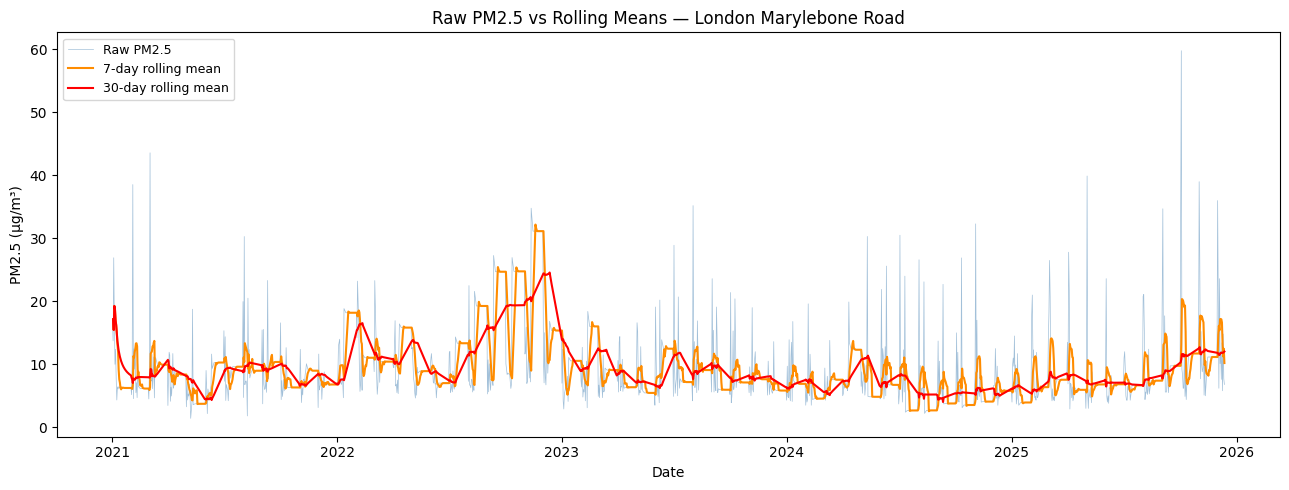

Saved: pm25_rolling_means.png


In [ ]:
# Rolling means
for window in [3, 7, 14, 30]:
    df[f'rolling_mean_{window}d'] = df['pm25'].shift(1).rolling(window, min_periods=1).mean()

# Rolling std, min, max
for window in [7, 30]:
    df[f'rolling_std_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=2).std()
    df[f'rolling_min_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).min()
    df[f'rolling_max_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).max()

rolling_features = (
    [f'rolling_mean_{w}d' for w in [3, 7, 14, 30]] +
    [f'rolling_std_{w}d'  for w in [7, 30]] +
    [f'rolling_min_{w}d'  for w in [7, 30]] +
    [f'rolling_max_{w}d'  for w in [7, 30]]
)

print(f'Rolling features added: {len(rolling_features)}')
print(rolling_features)

# Plot rolling means vs raw
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], df['pm25'], linewidth=0.5, color='steelblue', alpha=0.5, label='Raw PM2.5')
ax.plot(df['date'], df['rolling_mean_7d'],  linewidth=1.5, color='darkorange', label='7-day rolling mean')
ax.plot(df['date'], df['rolling_mean_30d'], linewidth=1.5, color='red',        label='30-day rolling mean')
ax.set_title('Raw PM2.5 vs Rolling Means — London Marylebone Road', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pm25_rolling_means.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_rolling_means.png')

In [ ]:
# Drop the target shift column before saving
df = df.drop(columns=['pm25_next_day'], errors='ignore')

df.to_csv('pm25_historical_features_updated.csv', index=False)
print('Saved: pm25_historical_features_updated.csv')

print(f"""
=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}

Lag features          : {len(lag_features)}
Rolling features      : {len(rolling_features)}
Rate of change        : {len(roc_features)}
Seasonal components   : {len(seasonal_features)}
Trend attributes      : {len(trend_attr_features)}
Cyclical features     : {len(cyclical_features)}
------------------------------
Total features added  : {len(all_features_updated)}
Final df shape        : {df.shape}
==============================
""")

df.head(10)

Saved: pm25_historical_features_updated.csv

=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-12
Total records  : 1,807

Lag features          : 6
Rolling features      : 10
Rate of change        : 6
Seasonal components   : 3
Trend attributes      : 14
Cyclical features     : 6
------------------------------
Total features added  : 45
Final df shape        : (1807, 50)



,date,pm25,station,was_observed,pm25_imputed,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_7d,pm25_lag_14d,...,trend_volatility_14d,trend_ratio_7d,trend_ratio_30d,trend_cumsum_7d,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos
0,2021-01-01,17.167,London Marylebone Road,True,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.017213,0.999852,-0.433884,-0.900969,0.201299,0.979530
1,2021-01-02,13.724,London Marylebone Road,True,False,17.167,NaN,NaN,NaN,NaN,...,NaN,1.000000,1.000000,17.167,0.034422,0.999407,-0.974928,-0.222521,0.394356,0.918958
2,2021-01-03,26.917,London Marylebone Road,True,False,13.724,17.167,NaN,NaN,NaN,...,2.434569,0.888544,0.888544,30.891,0.051620,0.998667,-0.781831,0.623490,0.571268,0.820763
3,2021-01-04,17.167,London Marylebone Road,True,False,26.917,13.724,17.167,NaN,NaN,...,6.843147,1.396883,1.396883,57.808,0.068802,0.997630,0.000000,1.000000,0.724793,0.688967
4,2021-01-05,10.000,London Marylebone Road,True,False,17.167,26.917,13.724,NaN,NaN,...,5.685425,0.915879,0.915879,74.975,0.085965,0.996298,0.781831,0.623490,0.848644,0.528964
5,2021-01-06,12.385,London Marylebone Road,True,False,10.000,17.167,26.917,NaN,NaN,...,6.287581,0.588408,0.588408,84.975,0.103102,0.994671,0.974928,-0.222521,0.937752,0.347305
6,2021-01-07,7.720,London Marylebone Road,True,False,12.385,10.000,17.167,NaN,NaN,...,5.930342,0.763250,0.763250,97.360,0.120208,0.992749,0.433884,-0.900969,0.988468,0.151428
7,2021-01-08,4.333,London Marylebone Road,True,False,7.720,12.385,10.000,17.167,NaN,...,6.296435,0.514275,0.514275,105.080,0.137279,0.990532,-0.433884,-0.900969,0.998717,-0.050649
8,2021-01-09,6.417,London Marylebone Road,True,False,4.333,7.720,12.385,13.724,NaN,...,6.945150,0.328806,0.316818,92.246,0.154309,0.988023,-0.974928,-0.222521,0.968077,-0.250653
9,2021-01-10,6.083,London Marylebone Road,True,False,6.417,4.333,7.720,26.917,NaN,...,6.932642,0.528838,0.498601,84.939,0.171293,0.985220,-0.781831,0.623490,0.897805,-0.440394


## 1.7. Rate of Change Features
How fast is PM2.5 changing? Captures pollution episodes building up or clearing.

Rate of change features added: ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

      date      pm25   diff_1d    diff_7d  diff_30d  pct_change_1d  pct_change_7d  diff_of_diff
2021-01-01 17.167000       NaN        NaN       NaN            NaN            NaN           NaN
2021-01-02 13.724000       NaN        NaN       NaN            NaN            NaN           NaN
2021-01-03 26.917000 -3.443000        NaN       NaN     -20.055921            NaN           NaN
2021-01-04 17.167000 13.193000        NaN       NaN      96.130866            NaN  1.663600e+01
2021-01-05 10.000000 -9.750000        NaN       NaN     -36.222462            NaN -2.294300e+01
2021-01-06 12.385000 -7.167000        NaN       NaN     -41.748704            NaN  2.583000e+00
2021-01-07  7.720000  2.385000        NaN       NaN      23.850000            NaN  9.552000e+00
2021-01-08  4.333000 -4.665000        NaN       NaN     -37.666532            NaN -7.050000e+00
2021-01-09  6.41700

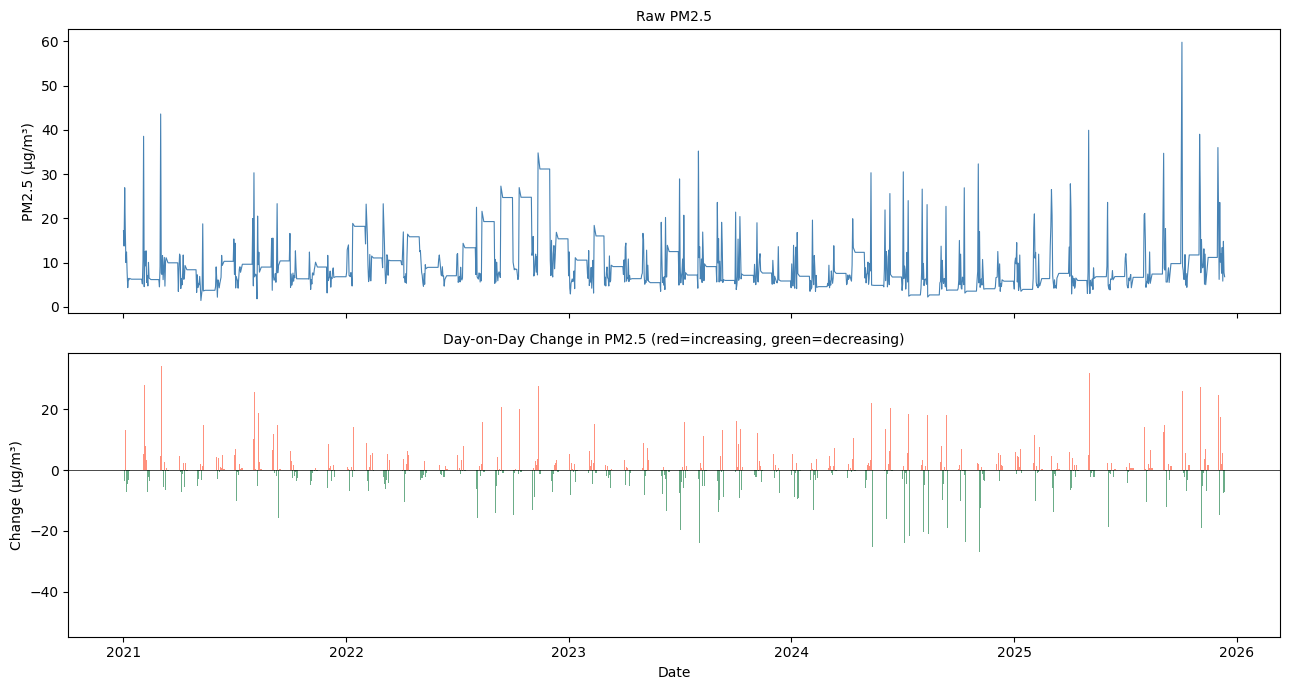

Saved: pm25_rate_of_change.png


In [ ]:
# Day-on-day difference (shift so we use yesterday's value, not today's)
df['diff_1d']      = df['pm25'].shift(1).diff(1)    # change from day before
df['diff_7d']      = df['pm25'].shift(1).diff(7)    # change over past 7 days
df['diff_30d']     = df['pm25'].shift(1).diff(30)   # change over past 30 days

# Percentage change from previous day
df['pct_change_1d'] = df['pm25'].shift(1).pct_change(1) * 100
df['pct_change_7d'] = df['pm25'].shift(1).pct_change(7) * 100

# Rate of acceleration (change of change)
df['diff_of_diff'] = df['diff_1d'].diff(1)

roc_features = ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

print(f'Rate of change features added: {roc_features}')
print()
print(df[['date', 'pm25'] + roc_features].head(15).to_string(index=False))

# Plot day-on-day difference
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(df['date'], df['pm25'], linewidth=0.8, color='steelblue')
axes[0].set_title('Raw PM2.5', fontsize=10)
axes[0].set_ylabel('PM2.5 (µg/m³)')

axes[1].bar(df['date'], df['diff_1d'], color=[
    'tomato' if x > 0 else 'seagreen' for x in df['diff_1d'].fillna(0)
], width=1, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Day-on-Day Change in PM2.5 (red=increasing, green=decreasing)', fontsize=10)
axes[1].set_ylabel('Change (µg/m³)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('pm25_rate_of_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_rate_of_change.png')

## 1.8. Seasonal Decomposition
Extract trend and seasonality components from the PM2.5 signal.

Seasonal features added: ['seasonal_trend', 'seasonal_component', 'seasonal_residual']


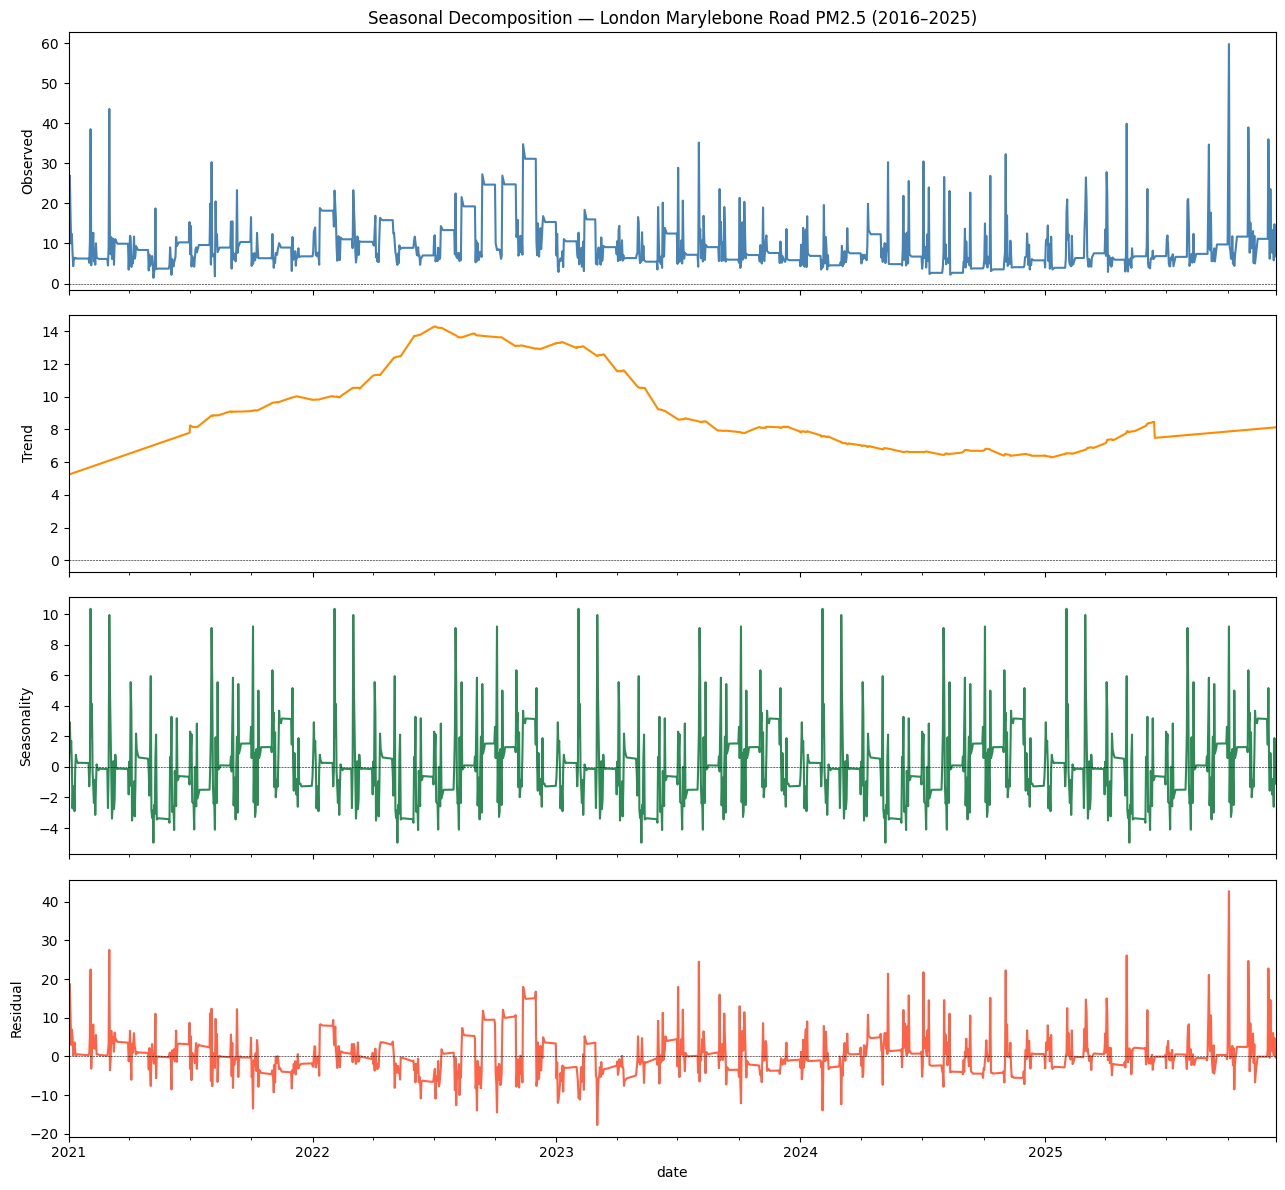

Saved: pm25_seasonal_decomposition.png


In [ ]:
# Seasonal decomposition — requires complete series with no NaNs
pm25_series = df.set_index('date')['pm25'].fillna(method='ffill')

# Annual seasonality period = 365 days
decomp = seasonal_decompose(pm25_series, model='additive', period=365, extrapolate_trend='freq')

# Add components back to df as features
df['seasonal_trend']      = decomp.trend.values
df['seasonal_component']  = decomp.seasonal.values
df['seasonal_residual']   = decomp.resid.values

seasonal_features = ['seasonal_trend', 'seasonal_component', 'seasonal_residual']
print(f'Seasonal features added: {seasonal_features}')

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
decomp.observed.plot(ax=axes[0],  color='steelblue');  axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1],     color='darkorange'); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2],  color='seagreen');   axes[2].set_ylabel('Seasonality')
decomp.resid.plot(ax=axes[3],     color='tomato');     axes[3].set_ylabel('Residual')

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.4, linestyle='--')

axes[0].set_title('Seasonal Decomposition — London Marylebone Road PM2.5 (2016–2025)', fontsize=12)
plt.tight_layout()
plt.savefig('pm25_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_seasonal_decomposition.png')

## 1.9. Extracted Trend Attributes (from Wood 2024)
Based on the univariate approach in Wood (2024) — extracting 15 trend attributes from prior PM2.5 recordings.

In [ ]:
# Rolling averages over different windows (using yesterday's value onwards)
for w in [3, 7, 14]:
    df[f'trend_avg_{w}d'] = df['pm25'].shift(1).rolling(w, min_periods=1).mean()

# Differences between specific past days
df['trend_diff_1_2']  = df['pm25'].shift(1) - df['pm25'].shift(2)   # yesterday vs 2 days ago
df['trend_diff_1_7']  = df['pm25'].shift(1) - df['pm25'].shift(7)   # yesterday vs last week
df['trend_diff_7_14'] = df['pm25'].shift(7) - df['pm25'].shift(14)  # last week vs 2 weeks ago

# Rates of change over different windows
df['trend_rate_3d']  = (df['pm25'].shift(1) - df['pm25'].shift(3))  / 3
df['trend_rate_7d']  = (df['pm25'].shift(1) - df['pm25'].shift(7))  / 7
df['trend_rate_14d'] = (df['pm25'].shift(1) - df['pm25'].shift(14)) / 14

# Volatility — rolling standard deviation
df['trend_volatility_7d']  = df['pm25'].shift(1).rolling(7,  min_periods=2).std()
df['trend_volatility_14d'] = df['pm25'].shift(1).rolling(14, min_periods=2).std()

# Ratio of current to rolling mean (how far from recent average)
df['trend_ratio_7d']  = df['pm25'].shift(1) / df[f'rolling_mean_7d'].replace(0, np.nan)
df['trend_ratio_30d'] = df['pm25'].shift(1) / df[f'rolling_mean_30d'].replace(0, np.nan)

# Cumulative sum over past 7 days (total pollution load)
df['trend_cumsum_7d'] = df['pm25'].shift(1).rolling(7, min_periods=1).sum()

trend_attr_features = [
    'trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d',
    'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14',
    'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d',
    'trend_volatility_7d', 'trend_volatility_14d',
    'trend_ratio_7d', 'trend_ratio_30d',
    'trend_cumsum_7d'
]

print(f'Trend attribute features added: {len(trend_attr_features)}')
print(trend_attr_features)
print()
print(df[['date', 'pm25'] + trend_attr_features].head(10).to_string(index=False))

Trend attribute features added: 14
['trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d', 'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14', 'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d', 'trend_volatility_7d', 'trend_volatility_14d', 'trend_ratio_7d', 'trend_ratio_30d', 'trend_cumsum_7d']

      date   pm25  trend_avg_3d  trend_avg_7d  trend_avg_14d  trend_diff_1_2  trend_diff_1_7  trend_diff_7_14  trend_rate_3d  trend_rate_7d  trend_rate_14d  trend_volatility_7d  trend_volatility_14d  trend_ratio_7d  trend_ratio_30d  trend_cumsum_7d
2021-01-01 17.167           NaN           NaN            NaN             NaN             NaN              NaN            NaN            NaN             NaN                  NaN                   NaN             NaN              NaN              NaN
2021-01-02 13.724     17.167000     17.167000      17.167000             NaN             NaN              NaN            NaN            NaN             NaN                  NaN                   NaN        

## 1.10. Cyclical Features
This section generates cyclical features for 'day of year', 'day of week', and 'day of month'. These features are encoded using sine and cosine transformations to represent their periodic nature, enabling models to capture daily, weekly, and annual fluctuations in PM2.5 levels.

In [ ]:
# Day of year
df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)

# Day of week (Monday=0, Sunday=6)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)

# Day of month
df['day_of_month_sin'] = np.sin(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)

cyclical_features = [
    'day_of_year_sin', 'day_of_year_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos'
]

print(f'Cyclical features added: {cyclical_features}')
print('\nSample (first 10 rows with new features):')
print(df[['date'] + cyclical_features].head(10).to_string(index=False))

Cyclical features added: ['day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_month_sin', 'day_of_month_cos']

Sample (first 10 rows with new features):
      date  day_of_year_sin  day_of_year_cos  day_of_week_sin  day_of_week_cos  day_of_month_sin  day_of_month_cos
2021-01-01         0.017213         0.999852        -0.433884        -0.900969          0.201299          0.979530
2021-01-02         0.034422         0.999407        -0.974928        -0.222521          0.394356          0.918958
2021-01-03         0.051620         0.998667        -0.781831         0.623490          0.571268          0.820763
2021-01-04         0.068802         0.997630         0.000000         1.000000          0.724793          0.688967
2021-01-05         0.085965         0.996298         0.781831         0.623490          0.848644          0.528964
2021-01-06         0.103102         0.994671         0.974928        -0.222521          0.937752          0.347305
2021-01-07

## 1.12. Feature Correlation with PM2.5 (Updated)
This section re-evaluates feature correlation with the next day's PM2.5 level, including newly added cyclical components. The top 15 features strongest correlated with future PM2.5 values are visualized to assess their predictive power.

Top 15 features correlated with next-day PM2.5 (updated):
rolling_mean_3d      0.588
trend_avg_3d         0.588
rolling_mean_7d      0.571
trend_avg_7d         0.571
trend_cumsum_7d      0.566
rolling_min_7d       0.546
pm25_lag_1d          0.543
rolling_mean_30d     0.538
pm25_lag_30d         0.525
trend_avg_14d        0.519
rolling_mean_14d     0.519
pm25_lag_2d          0.504
pm25_lag_3d          0.451
seasonal_residual    0.445
seasonal_trend       0.391


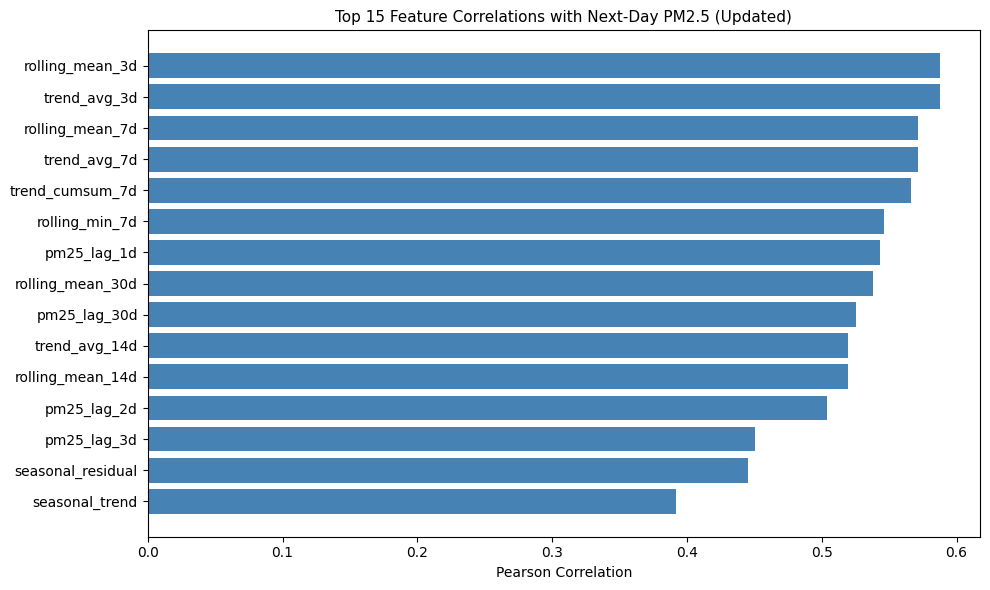

Saved: pm25_feature_correlations_updated.png


In [ ]:
all_features_updated = lag_features + rolling_features + roc_features + seasonal_features + trend_attr_features + cyclical_features

# Correlation with pm25 (next day — shifted back)
df['pm25_next_day'] = df['pm25'].shift(-1)  # target: tomorrow's PM2.5

corr_with_target_updated = (
    df[all_features_updated + ['pm25_next_day']]
    .corr()['pm25_next_day']
    .drop('pm25_next_day')
    .sort_values(ascending=False)
)

print('Top 15 features correlated with next-day PM2.5 (updated):')
print(corr_with_target_updated.head(15).round(3).to_string())

# Bar chart
top15_updated = corr_with_target_updated.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in top15_updated.values]
ax.barh(top15_updated.index[::-1], top15_updated.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Top 15 Feature Correlations with Next-Day PM2.5 (Updated)', fontsize=11)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('pm25_feature_correlations_updated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_feature_correlations_updated.png')


## 1.13. Save Output
This step saves the DataFrame, containing all engineered historical PM2.5 trend attributes and cyclical features, to `pm25_historical_features_updated.csv`. A summary of the feature engineering process and the final DataFrame shape is also displayed.

In [ ]:
# Drop the target shift column before saving
df = df.drop(columns=['pm25_next_day'], errors='ignore')

df.to_csv('pm25_historical_features_updated.csv', index=False)
print('Saved: pm25_historical_features_updated.csv')

print(f"""
=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}

Lag features          : {len(lag_features)}
Rolling features      : {len(rolling_features)}
Rate of change        : {len(roc_features)}
Seasonal components   : {len(seasonal_features)}
Trend attributes      : {len(trend_attr_features)}
Cyclical features     : {len(cyclical_features)}
------------------------------
Total features added  : {len(all_features_updated)}
Final df shape        : {df.shape}
==============================
""")

df.head(10)

Saved: pm25_historical_features_updated.csv

=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-12
Total records  : 1,807

Lag features          : 6
Rolling features      : 10
Rate of change        : 6
Seasonal components   : 3
Trend attributes      : 14
Cyclical features     : 6
------------------------------
Total features added  : 45
Final df shape        : (1807, 50)



,date,pm25,station,was_observed,pm25_imputed,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_7d,pm25_lag_14d,...,trend_volatility_14d,trend_ratio_7d,trend_ratio_30d,trend_cumsum_7d,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos
0,2021-01-01,17.167,London Marylebone Road,True,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.017213,0.999852,-0.433884,-0.900969,0.201299,0.979530
1,2021-01-02,13.724,London Marylebone Road,True,False,17.167,NaN,NaN,NaN,NaN,...,NaN,1.000000,1.000000,17.167,0.034422,0.999407,-0.974928,-0.222521,0.394356,0.918958
2,2021-01-03,26.917,London Marylebone Road,True,False,13.724,17.167,NaN,NaN,NaN,...,2.434569,0.888544,0.888544,30.891,0.051620,0.998667,-0.781831,0.623490,0.571268,0.820763
3,2021-01-04,17.167,London Marylebone Road,True,False,26.917,13.724,17.167,NaN,NaN,...,6.843147,1.396883,1.396883,57.808,0.068802,0.997630,0.000000,1.000000,0.724793,0.688967
4,2021-01-05,10.000,London Marylebone Road,True,False,17.167,26.917,13.724,NaN,NaN,...,5.685425,0.915879,0.915879,74.975,0.085965,0.996298,0.781831,0.623490,0.848644,0.528964
5,2021-01-06,12.385,London Marylebone Road,True,False,10.000,17.167,26.917,NaN,NaN,...,6.287581,0.588408,0.588408,84.975,0.103102,0.994671,0.974928,-0.222521,0.937752,0.347305
6,2021-01-07,7.720,London Marylebone Road,True,False,12.385,10.000,17.167,NaN,NaN,...,5.930342,0.763250,0.763250,97.360,0.120208,0.992749,0.433884,-0.900969,0.988468,0.151428
7,2021-01-08,4.333,London Marylebone Road,True,False,7.720,12.385,10.000,17.167,NaN,...,6.296435,0.514275,0.514275,105.080,0.137279,0.990532,-0.433884,-0.900969,0.998717,-0.050649
8,2021-01-09,6.417,London Marylebone Road,True,False,4.333,7.720,12.385,13.724,NaN,...,6.945150,0.328806,0.316818,92.246,0.154309,0.988023,-0.974928,-0.222521,0.968077,-0.250653
9,2021-01-10,6.083,London Marylebone Road,True,False,6.417,4.333,7.720,26.917,NaN,...,6.932642,0.528838,0.498601,84.939,0.171293,0.985220,-0.781831,0.623490,0.897805,-0.440394


## 1.11. Rebuilding DataFrame with All Features (to fix `NameError` and ensure all features are available for correlation)

In [ ]:
# Re-load raw data
def load_defra_single_station(filepath):
    raw = pd.read_csv(filepath, skiprows=11, header=None, usecols=[0, 1], names=['date', 'pm25'])
    raw = raw[raw['date'].astype(str).str.match(r'\d{4}|\d{2}/\d{2}/\d{4}', na=False)]
    raw['date'] = pd.to_datetime(raw['date'], dayfirst=True, errors='coerce').dt.normalize()
    raw['pm25'] = pd.to_numeric(raw['pm25'], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw

df = load_defra_single_station('/content/PM2.5_AirQualityDataDaily_2021-2025.csv')
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)
df['station'] = 'London Marylebone Road'

# Basic Cleaning
df = df[~(df['pm25'] < 0)].copy()
full_idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
df = df.set_index('date').reindex(full_idx).rename_axis('date').reset_index()
df['station'] = 'London Marylebone Road'

# Fill Missing Values
df['was_observed'] = df['pm25'].notna()
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3, limit_area='inside')
df['pm25'] = df['pm25'].ffill().bfill()
df['pm25_imputed'] = ~df['was_observed']

# Raw Lag Features
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'pm25_lag_{lag}d'] = df['pm25'].shift(lag)
lag_features = [f'pm25_lag_{lag}d' for lag in [1, 2, 3, 7, 14, 30]]

# Rolling Averages and Statistics
for window in [3, 7, 14, 30]:
    df[f'rolling_mean_{window}d'] = df['pm25'].shift(1).rolling(window, min_periods=1).mean()
for window in [7, 30]:
    df[f'rolling_std_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=2).std()
    df[f'rolling_min_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).min()
    df[f'rolling_max_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).max()
rolling_features = (
    [f'rolling_mean_{w}d' for w in [3, 7, 14, 30]] +
    [f'rolling_std_{w}d'  for w in [7, 30]] +
    [f'rolling_min_{w}d'  for w in [7, 30]] +
    [f'rolling_max_{w}d'  for w in [7, 30]]
)

# Rate of Change Features
df['diff_1d']      = df['pm25'].shift(1).diff(1)
df['diff_7d']      = df['pm25'].shift(1).diff(7)
df['diff_30d']     = df['pm25'].shift(1).diff(30)
df['pct_change_1d'] = df['pm25'].shift(1).pct_change(1) * 100
df['pct_change_7d'] = df['pm25'].shift(1).pct_change(7) * 100
df['diff_of_diff'] = df['diff_1d'].diff(1)
roc_features = ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

# Seasonal Decomposition
pm25_series = df.set_index('date')['pm25'].fillna(method='ffill')
decomp = seasonal_decompose(pm25_series, model='additive', period=365, extrapolate_trend='freq')
df['seasonal_trend']      = decomp.trend.values
df['seasonal_component']  = decomp.seasonal.values
df['seasonal_residual']   = decomp.resid.values
seasonal_features = ['seasonal_trend', 'seasonal_component', 'seasonal_residual']

# Extracted Trend Attributes (from Wood 2024)
for w in [3, 7, 14]:
    df[f'trend_avg_{w}d'] = df['pm25'].shift(1).rolling(w, min_periods=1).mean()
df['trend_diff_1_2']  = df['pm25'].shift(1) - df['pm25'].shift(2)
df['trend_diff_1_7']  = df['pm25'].shift(1) - df['pm25'].shift(7)
df['trend_diff_7_14'] = df['pm25'].shift(7) - df['pm25'].shift(14)
df['trend_rate_3d']  = (df['pm25'].shift(1) - df['pm25'].shift(3))  / 3
df['trend_rate_7d']  = (df['pm25'].shift(1) - df['pm25'].shift(7))  / 7
df['trend_rate_14d'] = (df['pm25'].shift(1) - df['pm25'].shift(14)) / 14
df['trend_volatility_7d']  = df['pm25'].shift(1).rolling(7,  min_periods=2).std()
df['trend_volatility_14d'] = df['pm25'].shift(1).rolling(14, min_periods=2).std()
df['trend_ratio_7d']  = df['pm25'].shift(1) / df[f'rolling_mean_7d'].replace(0, np.nan)
df['trend_ratio_30d'] = df['pm25'].shift(1) / df[f'rolling_mean_30d'].replace(0, np.nan)
df['trend_cumsum_7d'] = df['pm25'].shift(1).rolling(7, min_periods=1).sum()
trend_attr_features = [
    'trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d',
    'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14',
    'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d',
    'trend_volatility_7d', 'trend_volatility_14d',
    'trend_ratio_7d', 'trend_ratio_30d',
    'trend_cumsum_7d'
]

# Cyclical Features (from previous step)
df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_month_sin'] = np.sin(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
cyclical_features = [
    'day_of_year_sin', 'day_of_year_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos'
]

# Define the full list of features after all steps
all_features_updated = lag_features + rolling_features + roc_features + seasonal_features + trend_attr_features + cyclical_features

print(f'DataFrame rebuilt with all features. New shape: {df.shape}')
print(f'Total features in all_features_updated: {len(all_features_updated)}')
print(df.head())

DataFrame rebuilt with all features. New shape: (1807, 50)
Total features in all_features_updated: 45
        date    pm25                 station  was_observed  pm25_imputed  \
0 2021-01-01  17.167  London Marylebone Road          True         False   
1 2021-01-02  13.724  London Marylebone Road          True         False   
2 2021-01-03  26.917  London Marylebone Road          True         False   
3 2021-01-04  17.167  London Marylebone Road          True         False   
4 2021-01-05  10.000  London Marylebone Road          True         False   

   pm25_lag_1d  pm25_lag_2d  pm25_lag_3d  pm25_lag_7d  pm25_lag_14d  ...  \
0          NaN          NaN          NaN          NaN           NaN  ...   
1       17.167          NaN          NaN          NaN           NaN  ...   
2       13.724       17.167          NaN          NaN           NaN  ...   
3       26.917       13.724       17.167          NaN           NaN  ...   
4       17.167       26.917       13.724          NaN        

In [ ]:
# Day of year
df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)

# Day of week (Monday=0, Sunday=6)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)

# Day of month
df['day_of_month_sin'] = np.sin(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)

cyclical_features = [
    'day_of_year_sin', 'day_of_year_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos'
]

print(f'Cyclical features added: {cyclical_features}')
print('\nSample (first 10 rows with new features):')
print(df[['date'] + cyclical_features].head(10).to_string(index=False))

Cyclical features added: ['day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_month_sin', 'day_of_month_cos']

Sample (first 10 rows with new features):
      date  day_of_year_sin  day_of_year_cos  day_of_week_sin  day_of_week_cos  day_of_month_sin  day_of_month_cos
2016-01-01         0.017213         0.999852        -0.433884        -0.900969          0.201299          0.979530
2016-01-02         0.034422         0.999407        -0.974928        -0.222521          0.394356          0.918958
2016-01-03         0.051620         0.998667        -0.781831         0.623490          0.571268          0.820763
2016-01-04         0.068802         0.997630         0.000000         1.000000          0.724793          0.688967
2016-01-05         0.085965         0.996298         0.781831         0.623490          0.848644          0.528964
2016-01-06         0.103102         0.994671         0.974928        -0.222521          0.937752          0.347305
2016-01-07

# Task 2 — Complete Historical PM2.5 Data and Trend Attributes (Hiruni's Work)

## 2.1. Overview and Purpose
This notebook completes the feature engineering task for the group PM2.5 forecasting project.

It includes:

Historical PM2.5 data features.
Extracted trend attributes.
Seasonal components.
Spatiotemporal peer-station feature section with DTW logic.
Correct save path inside data/features/.

Important dataset note
The current uploaded dataset is a single-station daily dataset for London Marylebone Road. Therefore, true spatiotemporal peer-station features cannot be calculated from this dataset alone.

The notebook still includes the peer-station DTW section, but it only activates when the input dataset contains at least two stations.

Purpose of Historical PM2.5 data features.
This notebook performs feature engineering for PM2.5 air-quality forecasting. The aim is to transform raw daily PM2.5 observations into useful time-series features that can support machine learning forecasting models.

The engineered features include historical lag values, rolling trend attributes, rate-of-change measures, seasonal cyclical features, and a DTW-based peer-station feature section for future multi-station data.

## 2.2. Imports

In [17]:
from pathlib import Path
import csv
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Imports loaded successfully.")

Imports loaded successfully.


## 2.3. Setup Data and Output Directories

In [18]:
# =====================================
# Load uploaded UK-Air PM2.5 dataset
# =====================================

current_dir = Path.cwd()

# Works when notebook is in AIR/notebooks/
if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent

# Works when notebook is opened from AIR/
elif (current_dir / "data").exists():
    PROJECT_ROOT = current_dir

# Fallback for local machine
else:
    PROJECT_ROOT = Path.home() / "AIR"

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FEATURE_OUTPUT_DIR = PROJECT_ROOT / "data" / "features"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Current notebook folder:", current_dir)
print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Feature output folder:", FEATURE_OUTPUT_DIR)
print("Figure output folder:", FIGURE_DIR)

Current notebook folder: /content
Project root: /root/AIR
Raw data folder: /root/AIR/data/raw
Feature output folder: /root/AIR/data/features
Figure output folder: /root/AIR/outputs/figures


## 2.4. Load PM2.5 Dataset

In [20]:
DATA_FILE = Path("/content/PM2.5_AirQualityDataDaily_2021-2025.csv")

print("Looking for file:")
print(DATA_FILE)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"File not found: {DATA_FILE}\n"
        "Please place the CSV file inside data/raw/ in the GitHub project."
    )

def read_station_name(filepath):
    """Read station name from UK-Air metadata rows."""

    try:
        with open(filepath, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
            rows = list(csv.reader(f))

        station_name = rows[3][1].strip()

        if station_name.lower() in ["nan", "", "none"]:
            station_name = "London Marylebone Road"

    except Exception:
        station_name = "London Marylebone Road"

    return station_name


def load_defra_single_station(filepath):
    """
    Load a DEFRA/UK-Air single-station daily PM2.5 CSV file.

    The uploaded UK-Air file contains metadata rows followed by a data header:
    Date, PM2.5 particulate matter (Daily measured), Status
    """

    station_name = read_station_name(filepath)

    # Read actual data after metadata rows
    raw = pd.read_csv(filepath, skiprows=10, header=0)

    raw = raw.rename(columns={
        raw.columns[0]: "date",
        raw.columns[1]: "pm25_raw"
    })

    if raw.shape[1] >= 3:
        raw = raw.rename(columns={raw.columns[2]: "status_raw"})
    else:
        raw["status_raw"] = np.nan

    raw["date_raw"] = raw["date"].astype(str)

    # Correct for ISO date format such as 2021-01-01
    raw["date"] = pd.to_datetime(
        raw["date_raw"],
        format="%Y-%m-%d",
        errors="coerce"
    )

    # Fallback for any non-ISO date rows
    missing_dates = raw["date"].isna()

    if missing_dates.any():
        raw.loc[missing_dates, "date"] = pd.to_datetime(
            raw.loc[missing_dates, "date_raw"],
            errors="coerce",
            dayfirst=True
        )

    raw["pm25_raw"] = pd.to_numeric(raw["pm25_raw"], errors="coerce")

    raw = raw.dropna(subset=["date"]).copy()
    raw["date"] = raw["date"].dt.normalize()

    raw["station"] = station_name
    raw["source_file"] = Path(filepath).name

    raw = raw[[
        "date",
        "date_raw",
        "station",
        "pm25_raw",
        "status_raw",
        "source_file"
    ]]

    raw = (
        raw
        .sort_values(["station", "date"])
        .drop_duplicates(subset=["station", "date"])
        .reset_index(drop=True)
    )

    return raw

df = load_defra_single_station(DATA_FILE)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)
print("Station:", df["station"].iloc[0])
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Missing PM2.5 count:", df["pm25_raw"].isna().sum())
print("Missing PM2.5 percentage:", round(df["pm25_raw"].isna().mean() * 100, 2), "%")
df.head(10)

Looking for file:
/content/PM2.5_AirQualityDataDaily_2021-2025.csv

Dataset loaded successfully.
Shape: (1825, 6)
Station: London Marylebone Road
Date range: 2021-01-01 00:00:00 to 2025-12-30 00:00:00
Missing PM2.5 count: 86
Missing PM2.5 percentage: 4.71 %


,date,date_raw,station,pm25_raw,status_raw,source_file
0,2021-01-01,2021-01-01,London Marylebone Road,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
1,2021-01-02,2021-01-02,London Marylebone Road,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
2,2021-01-03,2021-01-03,London Marylebone Road,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
3,2021-01-04,2021-01-04,London Marylebone Road,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
4,2021-01-05,2021-01-05,London Marylebone Road,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
5,2021-01-06,2021-01-06,London Marylebone Road,4.542,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
6,2021-01-07,2021-01-07,London Marylebone Road,15.333,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
7,2021-01-08,2021-01-08,London Marylebone Road,19.958,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
8,2021-01-09,2021-01-09,London Marylebone Road,15.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
9,2021-01-10,2021-01-10,London Marylebone Road,16.583,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv


## 2.5. Complete Daily Date Index

In [28]:
full_station_frames = []

for station, station_df in df.groupby("station"):

    full_dates = pd.date_range(
        station_df["date"].min(),
        station_df["date"].max(),
        freq="D"
    )

    full_station = pd.DataFrame({
        "date": full_dates,
        "station": station
    })

    full_station = full_station.merge(
        station_df,
        on=["date", "station"],
        how="left"
    )

    full_station_frames.append(full_station)

df = pd.concat(full_station_frames, ignore_index=True)

df["source_file"] = df["source_file"].fillna(DATA_FILE.name)
df["date_raw"] = df["date_raw"].fillna(df["date"].dt.strftime("%Y-%m-%d"))
df["status_raw"] = df["status_raw"].fillna("Missing calendar day")

df["pm25_missing_flag"] = df["pm25_raw"].isna().astype(int)

print("Completed daily date index.")
print("Shape after daily completion:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Missing PM2.5 count:", df["pm25_raw"].isna().sum())

df.head()

Completed daily date index.
Shape after daily completion: (1825, 58)
Date range: 2021-01-01 00:00:00 to 2025-12-30 00:00:00
Missing PM2.5 count: 86


,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag,pm25_for_features,pm25_lag_1d,pm25_lag_2d,...,pm25_diff_3d,pm25_rate_change_3d,pm25_diff_6d,pm25_rate_change_6d,pm25_diff_7d,pm25_rate_change_7d,pm25_diff_12d,pm25_rate_change_12d,pm25_diff_14d,pm25_rate_change_14d
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,17.167,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,5.167,17.167,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,4.500,5.167,17.167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,3.458,4.500,5.167,...,-12.667,-0.737869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,3.250,3.458,4.500,...,-1.709,-0.330753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.6. Timestamp and Seasonal Base Features

In [29]:
df = df.sort_values(["station", "date"]).reset_index(drop=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_year"] = df["date"].dt.dayofyear
df["day_of_week"] = df["date"].dt.day_name()
df["quarter"] = df["date"].dt.quarter

print("Timestamp features created.")

df.head()

Timestamp features created.


,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag,pm25_for_features,pm25_lag_1d,pm25_lag_2d,...,pm25_diff_12d,pm25_rate_change_12d,pm25_diff_14d,pm25_rate_change_14d,year,month,day,day_of_year,day_of_week,quarter
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,17.167,NaN,NaN,...,NaN,NaN,NaN,NaN,2021,1,1,1,Friday,1
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,5.167,17.167,NaN,...,NaN,NaN,NaN,NaN,2021,1,2,2,Saturday,1
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,4.500,5.167,17.167,...,NaN,NaN,NaN,NaN,2021,1,3,3,Sunday,1
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,3.458,4.500,5.167,...,NaN,NaN,NaN,NaN,2021,1,4,4,Monday,1
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,3.250,3.458,4.500,...,NaN,NaN,NaN,NaN,2021,1,5,5,Tuesday,1


## 2.7. PM2.5 Column for Feature Engineering

In [22]:
df["pm25_for_features"] = (
    df.groupby("station")["pm25_raw"]
    .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
)

PM25_FEATURE_COL = "pm25_for_features"

print("Feature source column:", PM25_FEATURE_COL)
print("Missing values in raw PM2.5:", df["pm25_raw"].isna().sum())
print("Missing values in feature PM2.5:", df[PM25_FEATURE_COL].isna().sum())

df[["date", "station", "pm25_raw", "pm25_for_features", "pm25_missing_flag"]].head(15)

Feature source column: pm25_for_features
Missing values in raw PM2.5: 86
Missing values in feature PM2.5: 0


,date,station,pm25_raw,pm25_for_features,pm25_missing_flag
0,2021-01-01,London Marylebone Road,17.167,17.167,0
1,2021-01-02,London Marylebone Road,5.167,5.167,0
2,2021-01-03,London Marylebone Road,4.500,4.500,0
3,2021-01-04,London Marylebone Road,3.458,3.458,0
4,2021-01-05,London Marylebone Road,3.250,3.250,0
5,2021-01-06,London Marylebone Road,4.542,4.542,0
6,2021-01-07,London Marylebone Road,15.333,15.333,0
7,2021-01-08,London Marylebone Road,19.958,19.958,0
8,2021-01-09,London Marylebone Road,15.458,15.458,0
9,2021-01-10,London Marylebone Road,16.583,16.583,0


## 2.8. Historical PM2.5 Lag Features

In [23]:
lag_days = [1, 2, 3, 6, 7, 12, 14, 30]

for lag in lag_days:
    df[f"pm25_lag_{lag}d"] = (
        df.groupby("station")[PM25_FEATURE_COL]
        .shift(lag)
    )

lag_feature_cols = [f"pm25_lag_{lag}d" for lag in lag_days]

print("Historical PM2.5 lag features created:")
print(lag_feature_cols)

df[["date", "station", "pm25_raw", PM25_FEATURE_COL] + lag_feature_cols].head(15)

Historical PM2.5 lag features created:
['pm25_lag_1d', 'pm25_lag_2d', 'pm25_lag_3d', 'pm25_lag_6d', 'pm25_lag_7d', 'pm25_lag_12d', 'pm25_lag_14d', 'pm25_lag_30d']


,date,station,pm25_raw,pm25_for_features,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_6d,pm25_lag_7d,pm25_lag_12d,pm25_lag_14d,pm25_lag_30d
0,2021-01-01,London Marylebone Road,17.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,5.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,London Marylebone Road,4.500,4.500,5.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,London Marylebone Road,3.458,3.458,4.500,5.167,17.167,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,London Marylebone Road,3.250,3.250,3.458,4.500,5.167,NaN,NaN,NaN,NaN,NaN
5,2021-01-06,London Marylebone Road,4.542,4.542,3.250,3.458,4.500,NaN,NaN,NaN,NaN,NaN
6,2021-01-07,London Marylebone Road,15.333,15.333,4.542,3.250,3.458,17.167,NaN,NaN,NaN,NaN
7,2021-01-08,London Marylebone Road,19.958,19.958,15.333,4.542,3.250,5.167,17.167,NaN,NaN,NaN
8,2021-01-09,London Marylebone Road,15.458,15.458,19.958,15.333,4.542,4.500,5.167,NaN,NaN,NaN
9,2021-01-10,London Marylebone Road,16.583,16.583,15.458,19.958,15.333,3.458,4.500,NaN,NaN,NaN


## 2.9. Extracted Trend Attributes

In [24]:
shifted_pm25 = df.groupby("station")[PM25_FEATURE_COL].shift(1)

rolling_windows = [3, 6, 7, 12, 14, 30]

for window in rolling_windows:

    df[f"pm25_roll_mean_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_std_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=2)
        .std()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_min_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .min()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_max_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .max()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_range_{window}d"] = (
        df[f"pm25_roll_max_{window}d"] - df[f"pm25_roll_min_{window}d"]
    )

rolling_feature_cols = [
    col for col in df.columns
    if col.startswith("pm25_roll_")
]

print("Rolling trend features created:", len(rolling_feature_cols))
print(rolling_feature_cols)

df[["date", "station", PM25_FEATURE_COL] + rolling_feature_cols].head(15)

Rolling trend features created: 30
['pm25_roll_mean_3d', 'pm25_roll_std_3d', 'pm25_roll_min_3d', 'pm25_roll_max_3d', 'pm25_roll_range_3d', 'pm25_roll_mean_6d', 'pm25_roll_std_6d', 'pm25_roll_min_6d', 'pm25_roll_max_6d', 'pm25_roll_range_6d', 'pm25_roll_mean_7d', 'pm25_roll_std_7d', 'pm25_roll_min_7d', 'pm25_roll_max_7d', 'pm25_roll_range_7d', 'pm25_roll_mean_12d', 'pm25_roll_std_12d', 'pm25_roll_min_12d', 'pm25_roll_max_12d', 'pm25_roll_range_12d', 'pm25_roll_mean_14d', 'pm25_roll_std_14d', 'pm25_roll_min_14d', 'pm25_roll_max_14d', 'pm25_roll_range_14d', 'pm25_roll_mean_30d', 'pm25_roll_std_30d', 'pm25_roll_min_30d', 'pm25_roll_max_30d', 'pm25_roll_range_30d']


,date,station,pm25_for_features,pm25_roll_mean_3d,pm25_roll_std_3d,pm25_roll_min_3d,pm25_roll_max_3d,pm25_roll_range_3d,pm25_roll_mean_6d,pm25_roll_std_6d,...,pm25_roll_mean_14d,pm25_roll_std_14d,pm25_roll_min_14d,pm25_roll_max_14d,pm25_roll_range_14d,pm25_roll_mean_30d,pm25_roll_std_30d,pm25_roll_min_30d,pm25_roll_max_30d,pm25_roll_range_30d
0,2021-01-01,London Marylebone Road,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,17.167000,NaN,17.167,17.167,0.000,17.167000,NaN,...,17.167000,NaN,17.167,17.167,0.000,17.167000,NaN,17.167,17.167,0.000
2,2021-01-03,London Marylebone Road,4.500,11.167000,8.485281,5.167,17.167,12.000,11.167000,8.485281,...,11.167000,8.485281,5.167,17.167,12.000,11.167000,8.485281,5.167,17.167,12.000
3,2021-01-04,London Marylebone Road,3.458,8.944667,7.128555,4.500,17.167,12.667,8.944667,7.128555,...,8.944667,7.128555,4.500,17.167,12.667,8.944667,7.128555,4.500,17.167,12.667
4,2021-01-05,London Marylebone Road,3.250,4.375000,0.861330,3.458,5.167,1.709,7.573000,6.434548,...,7.573000,6.434548,3.458,17.167,13.709,7.573000,6.434548,3.458,17.167,13.709
5,2021-01-06,London Marylebone Road,4.542,3.736000,0.669767,3.250,4.500,1.250,6.708400,5.898324,...,6.708400,5.898324,3.250,17.167,13.917,6.708400,5.898324,3.250,17.167,13.917
6,2021-01-07,London Marylebone Road,15.333,3.750000,0.693732,3.250,4.542,1.292,6.347333,5.349242,...,6.347333,5.349242,3.250,17.167,13.917,6.347333,5.349242,3.250,17.167,13.917
7,2021-01-08,London Marylebone Road,19.958,7.708333,6.634680,3.250,15.333,12.083,6.041667,4.608436,...,7.631000,5.948103,3.250,17.167,13.917,7.631000,5.948103,3.250,17.167,13.917
8,2021-01-09,London Marylebone Road,15.458,13.277667,7.910851,4.542,19.958,15.416,8.506833,7.247419,...,9.171875,7.022821,3.250,19.958,16.708,9.171875,7.022821,3.250,19.958,16.708
9,2021-01-10,London Marylebone Road,16.583,16.916333,2.634902,15.333,19.958,4.625,10.333167,7.414532,...,9.870333,6.895333,3.250,19.958,16.708,9.870333,6.895333,3.250,19.958,16.708


In [25]:
# =========================================================
# Difference and rate-of-change trend features
# =========================================================

difference_gaps = [1, 3, 6, 7, 12, 14]

for gap in difference_gaps:

    if f"pm25_lag_{gap}d" in df.columns:
        df[f"pm25_diff_{gap}d"] = (
            df["pm25_lag_1d"] - df[f"pm25_lag_{gap}d"]
        )

        df[f"pm25_rate_change_{gap}d"] = (
            df[f"pm25_diff_{gap}d"] / (df[f"pm25_lag_{gap}d"] + 1e-6)
        )

trend_change_cols = [
    col for col in df.columns
    if col.startswith("pm25_diff_")
    or col.startswith("pm25_rate_change_")
]

print("Difference and rate-of-change features created:", len(trend_change_cols))
print(trend_change_cols)

df[["date", "station", PM25_FEATURE_COL] + trend_change_cols].head(15)

Difference and rate-of-change features created: 12
['pm25_diff_1d', 'pm25_rate_change_1d', 'pm25_diff_3d', 'pm25_rate_change_3d', 'pm25_diff_6d', 'pm25_rate_change_6d', 'pm25_diff_7d', 'pm25_rate_change_7d', 'pm25_diff_12d', 'pm25_rate_change_12d', 'pm25_diff_14d', 'pm25_rate_change_14d']


,date,station,pm25_for_features,pm25_diff_1d,pm25_rate_change_1d,pm25_diff_3d,pm25_rate_change_3d,pm25_diff_6d,pm25_rate_change_6d,pm25_diff_7d,pm25_rate_change_7d,pm25_diff_12d,pm25_rate_change_12d,pm25_diff_14d,pm25_rate_change_14d
0,2021-01-01,London Marylebone Road,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,London Marylebone Road,4.500,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,London Marylebone Road,3.458,0.0,0.0,-12.667,-0.737869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,London Marylebone Road,3.250,0.0,0.0,-1.709,-0.330753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021-01-06,London Marylebone Road,4.542,0.0,0.0,-1.250,-0.277778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021-01-07,London Marylebone Road,15.333,0.0,0.0,1.084,0.313476,-12.625,-0.735423,NaN,NaN,NaN,NaN,NaN,NaN
7,2021-01-08,London Marylebone Road,19.958,0.0,0.0,12.083,3.717845,10.166,1.967486,-1.834,-0.106833,NaN,NaN,NaN,NaN
8,2021-01-09,London Marylebone Road,15.458,0.0,0.0,15.416,3.394099,15.458,3.435110,14.791,2.862589,NaN,NaN,NaN,NaN
9,2021-01-10,London Marylebone Road,16.583,0.0,0.0,0.125,0.008152,12.000,3.470213,10.958,2.435111,NaN,NaN,NaN,NaN


## 2.10. Seasonal Cyclical Components

In [30]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

seasonal_feature_cols = [
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

print("Seasonal cyclical features created:")
print(seasonal_feature_cols)

df[["date", "station", "month", "day_of_year"] + seasonal_feature_cols].head(10)

Seasonal cyclical features created:
['month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']


,date,station,month,day_of_year,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,2021-01-01,London Marylebone Road,1,1,0.5,0.866025,0.017202,0.999852
1,2021-01-02,London Marylebone Road,1,2,0.5,0.866025,0.034398,0.999408
2,2021-01-03,London Marylebone Road,1,3,0.5,0.866025,0.051584,0.998669
3,2021-01-04,London Marylebone Road,1,4,0.5,0.866025,0.068755,0.997634
4,2021-01-05,London Marylebone Road,1,5,0.5,0.866025,0.085906,0.996303
5,2021-01-06,London Marylebone Road,1,6,0.5,0.866025,0.103031,0.994678
6,2021-01-07,London Marylebone Road,1,7,0.5,0.866025,0.120126,0.992759
7,2021-01-08,London Marylebone Road,1,8,0.5,0.866025,0.137185,0.990545
8,2021-01-09,London Marylebone Road,1,9,0.5,0.866025,0.154204,0.988039
9,2021-01-10,London Marylebone Road,1,10,0.5,0.866025,0.171177,0.985240


## 2.11. Spatiotemporal Peer Station Features using DTW

In [31]:
def zscore_array(values):
    values = np.asarray(values, dtype=float)
    return (values - np.nanmean(values)) / (np.nanstd(values) + 1e-6)


def prepare_series_for_similarity(series):
    return (
        series
        .interpolate(limit_direction="both")
        .ffill()
        .bfill()
    )


def dtw_distance_windowed(series_a, series_b, window=8):
    valid_mask = series_a.notna() & series_b.notna()

    a = series_a[valid_mask].values
    b = series_b[valid_mask].values

    if len(a) < 10 or len(b) < 10:
        return np.inf

    a = zscore_array(a)
    b = zscore_array(b)

    n = len(a)
    m = len(b)

    window = max(window, abs(n - m))

    previous = np.full(m + 1, np.inf)
    previous[0] = 0

    for i in range(1, n + 1):
        current = np.full(m + 1, np.inf)

        j_start = max(1, i - window)
        j_end = min(m, i + window)

        for j in range(j_start, j_end + 1):
            cost = abs(a[i - 1] - b[j - 1])
            current[j] = cost + min(
                previous[j],
                current[j - 1],
                previous[j - 1]
            )

        previous = current

    return previous[m] / (n + m)


station_count = df["station"].nunique()

print("Number of stations:", station_count)

peer_station_df = pd.DataFrame()
peer_features_df = pd.DataFrame()

if station_count < 2:

    print(
        "Peer-station DTW features are not available because this dataset "
        "contains only one monitoring station."
    )

    df["peer_feature_available"] = False
    df["peer_feature_note"] = "Not available: single-station dataset."

else:

    pm25_wide = df.pivot_table(
        index="date",
        columns="station",
        values=PM25_FEATURE_COL,
        aggfunc="mean"
    ).sort_index()

    stations = pm25_wide.columns.tolist()

    pm25_similarity = (
        pm25_wide
        .apply(prepare_series_for_similarity)
        .resample("7D")
        .mean()
    )

    peer_records = []

    for station in stations:

        distances = []

        for peer_station in stations:

            if station == peer_station:
                continue

            distance = dtw_distance_windowed(
                pm25_similarity[station],
                pm25_similarity[peer_station],
                window=8
            )

            distances.append({
                "station": station,
                "peer_station": peer_station,
                "dtw_distance": distance
            })

        station_peer_df = (
            pd.DataFrame(distances)
            .sort_values("dtw_distance")
            .reset_index(drop=True)
        )

        number_of_peers = min(3, len(station_peer_df))

        top_peers = station_peer_df.head(number_of_peers).copy()
        top_peers["peer_rank"] = range(1, number_of_peers + 1)

        peer_records.append(top_peers)

    peer_station_df = pd.concat(peer_records, ignore_index=True)

    peer_feature_rows = []

    for station in stations:

        selected_peer_info = peer_station_df[
            peer_station_df["station"] == station
        ].copy()

        selected_peers = selected_peer_info["peer_station"].tolist()

        peer_values = pm25_wide[selected_peers]

        distances = selected_peer_info["dtw_distance"].values
        weights = 1 / (distances + 1e-6)
        weights = weights / weights.sum()

        weighted_peer_lag_1d = (
            peer_values.shift(1)
            .multiply(weights, axis=1)
            .sum(axis=1)
        )

        peer_features = pd.DataFrame({
            "date": pm25_wide.index,
            "station": station,
            "peer_pm25_mean_lag_1d": peer_values.shift(1).mean(axis=1),
            "peer_pm25_median_lag_1d": peer_values.shift(1).median(axis=1),
            "peer_pm25_max_lag_1d": peer_values.shift(1).max(axis=1),
            "peer_pm25_min_lag_1d": peer_values.shift(1).min(axis=1),
            "peer_pm25_weighted_lag_1d": weighted_peer_lag_1d,
            "peer_pm25_mean_lag_3d": peer_values.shift(3).mean(axis=1),
            "peer_pm25_mean_lag_7d": peer_values.shift(7).mean(axis=1),
            "peer_pm25_roll_mean_7d": (
                peer_values
                .shift(1)
                .rolling(window=7, min_periods=1)
                .mean()
                .mean(axis=1)
            ),
            "peer_station_count": len(selected_peers)
        })

        peer_feature_rows.append(peer_features)

    peer_features_df = pd.concat(peer_feature_rows, ignore_index=True)

    df = df.merge(
        peer_features_df,
        on=["date", "station"],
        how="left"
    )

    df["peer_feature_available"] = True
    df["peer_feature_note"] = "Available: multi-station DTW peer features created."

    print("DTW peer features created successfully.")

peer_station_df.head()

Number of stations: 1
Peer-station DTW features are not available because this dataset contains only one monitoring station.


""


## 2.11.1. Graphs for Feature Engineering Evidence

### Raw PM2.5 Time-Series Graph

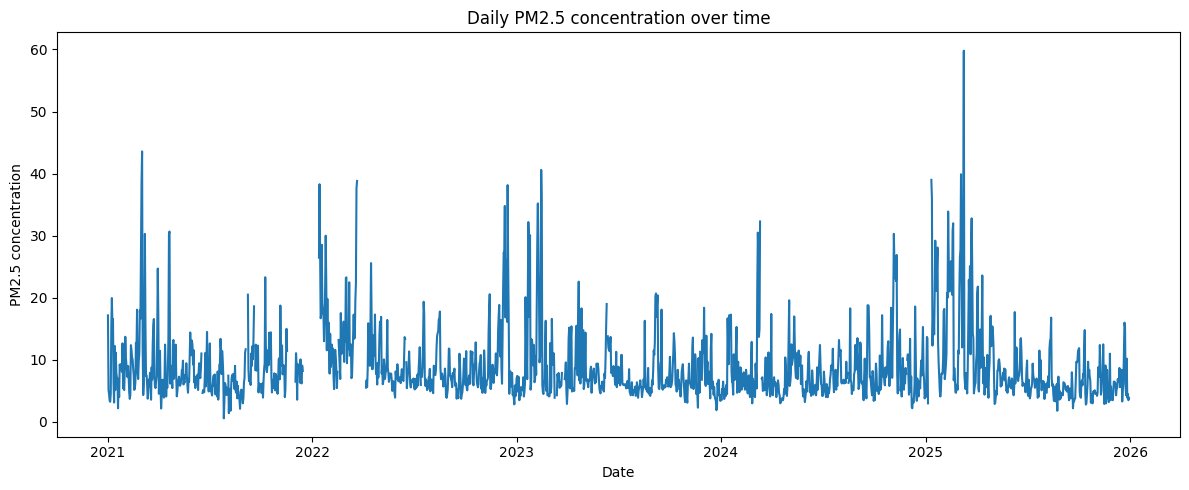

Saved: /content/figures/daily_pm25_time_series.png


In [37]:
import matplotlib.pyplot as plt

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Use PM2.5 column for plotting
plot_col = "pm25_raw"

# 1. Raw PM2.5 time-series graph
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df[plot_col])
plt.title("Daily PM2.5 concentration over time")
plt.xlabel("Date")
plt.ylabel("PM2.5 concentration")
plt.tight_layout()

time_series_path = FIGURE_DIR / "daily_pm25_time_series.png"
plt.savefig(time_series_path, dpi=300)
plt.show()

print("Saved:", time_series_path)

### PM2.5 with Rolling Mean Trend

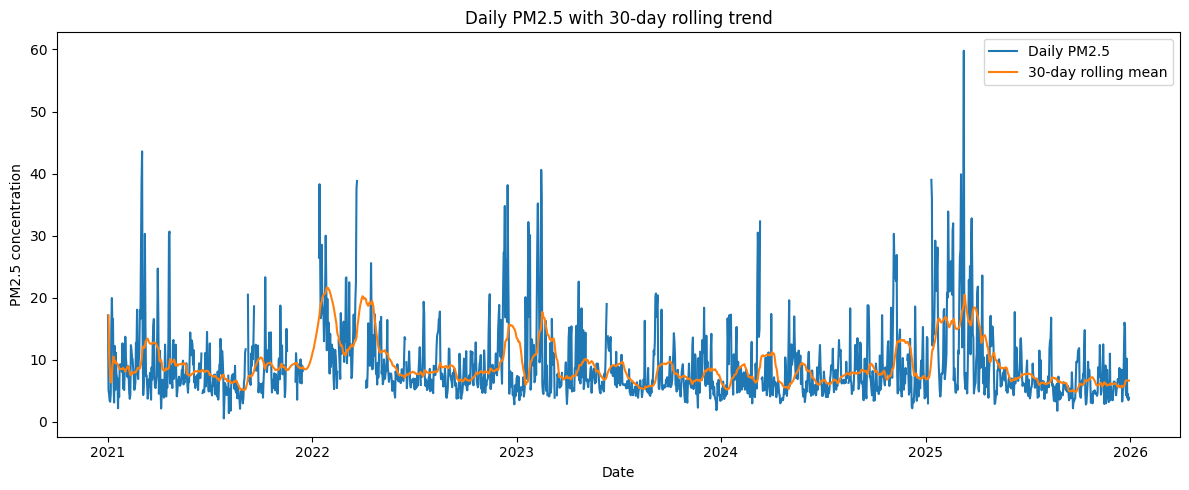

Saved: /content/figures/pm25_30_day_rolling_trend.png


In [38]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["pm25_raw"], label="Daily PM2.5")
plt.plot(df["date"], df["pm25_roll_mean_30d"], label="30-day rolling mean")
plt.title("Daily PM2.5 with 30-day rolling trend")
plt.xlabel("Date")
plt.ylabel("PM2.5 concentration")
plt.legend()
plt.tight_layout()

rolling_trend_path = FIGURE_DIR / "pm25_30_day_rolling_trend.png"
plt.savefig(rolling_trend_path, dpi=300)
plt.show()

print("Saved:", rolling_trend_path)

### Monthly Average PM2.5 Trend

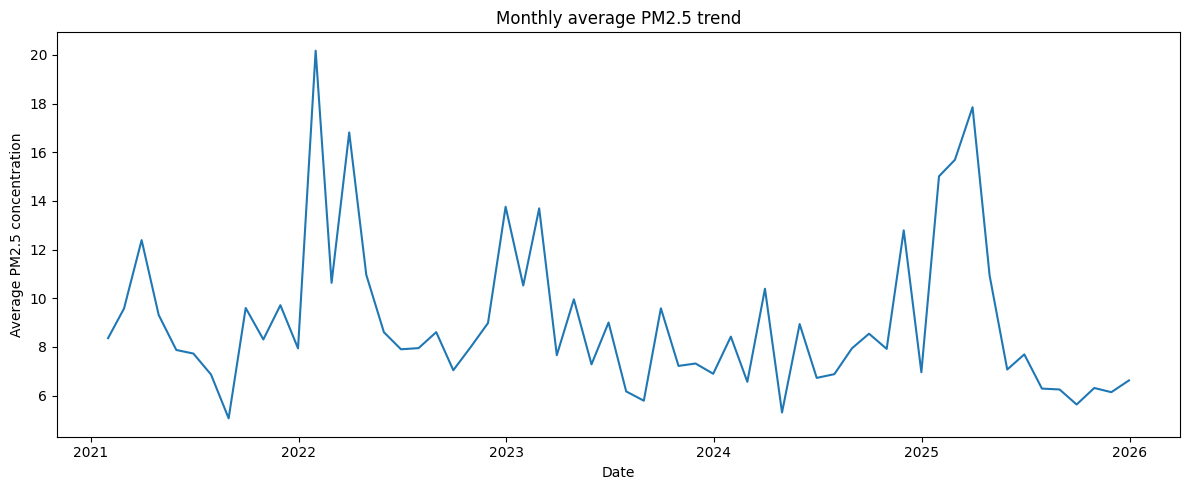

Saved: /content/figures/monthly_average_pm25_trend.png


In [39]:
monthly_pm25 = (
    df.set_index("date")["pm25_raw"]
    .resample("M")
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_pm25["date"], monthly_pm25["pm25_raw"])
plt.title("Monthly average PM2.5 trend")
plt.xlabel("Date")
plt.ylabel("Average PM2.5 concentration")
plt.tight_layout()

monthly_trend_path = FIGURE_DIR / "monthly_average_pm25_trend.png"
plt.savefig(monthly_trend_path, dpi=300)
plt.show()

print("Saved:", monthly_trend_path)

### Missing PM2.5 Values by Year

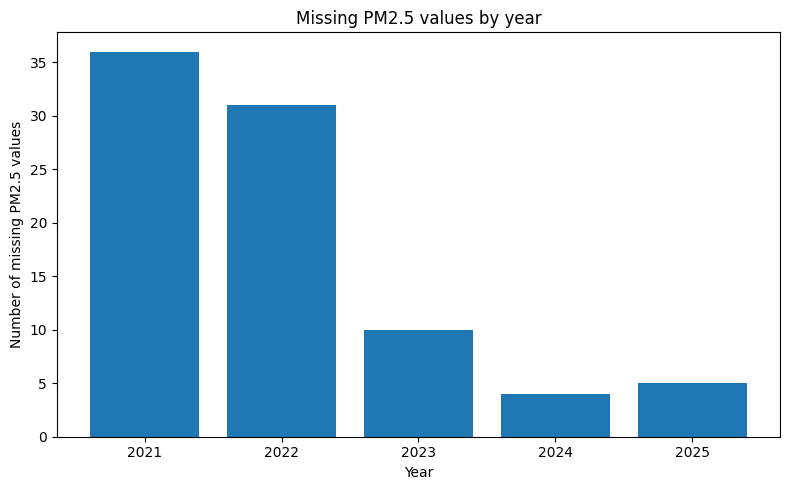

Saved: /content/figures/missing_pm25_values_by_year.png


In [40]:
missing_by_year = (
    df.groupby("year")["pm25_missing_flag"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(missing_by_year["year"].astype(str), missing_by_year["pm25_missing_flag"])
plt.title("Missing PM2.5 values by year")
plt.xlabel("Year")
plt.ylabel("Number of missing PM2.5 values")
plt.tight_layout()

missing_year_path = FIGURE_DIR / "missing_pm25_values_by_year.png"
plt.savefig(missing_year_path, dpi=300)
plt.show()

print("Saved:", missing_year_path)

## 2.12. Final Feature Summary and Save Outputs

In [32]:
## 2.12. Final Feature Summary and Save Outputs

Number of engineered features: 55

Feature columns:
-  pm25_missing_flag
-  pm25_lag_1d
-  pm25_lag_2d
-  pm25_lag_3d
-  pm25_lag_6d
-  pm25_lag_7d
-  pm25_lag_12d
-  pm25_lag_14d
-  pm25_lag_30d
-  pm25_roll_mean_3d
-  pm25_roll_std_3d
-  pm25_roll_min_3d
-  pm25_roll_max_3d
-  pm25_roll_range_3d
-  pm25_roll_mean_6d
-  pm25_roll_std_6d
-  pm25_roll_min_6d
-  pm25_roll_max_6d
-  pm25_roll_range_6d
-  pm25_roll_mean_7d
-  pm25_roll_std_7d
-  pm25_roll_min_7d
-  pm25_roll_max_7d
-  pm25_roll_range_7d
-  pm25_roll_mean_12d
-  pm25_roll_std_12d
-  pm25_roll_min_12d
-  pm25_roll_max_12d
-  pm25_roll_range_12d
-  pm25_roll_mean_14d
-  pm25_roll_std_14d
-  pm25_roll_min_14d
-  pm25_roll_max_14d
-  pm25_roll_range_14d
-  pm25_roll_mean_30d
-  pm25_roll_std_30d
-  pm25_roll_min_30d
-  pm25_roll_max_30d
-  pm25_roll_range_30d
-  pm25_diff_1d
-  pm25_rate_change_1d
-  pm25_diff_3d
-  pm25_rate_change_3d
-  pm25_diff_6d
-  pm25_rate_change_6d
-  pm25_diff_7d
-  pm25_rate_change_7d
-  pm25_diff_12

,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag,pm25_for_features,pm25_lag_1d,pm25_lag_2d,...,day,day_of_year,day_of_week,quarter,month_sin,month_cos,day_of_year_sin,day_of_year_cos,peer_feature_available,peer_feature_note
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,17.167,NaN,NaN,...,1,1,Friday,1,0.5,0.866025,0.017202,0.999852,False,Not available: single-station dataset.
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,5.167,17.167,NaN,...,2,2,Saturday,1,0.5,0.866025,0.034398,0.999408,False,Not available: single-station dataset.
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,4.500,5.167,17.167,...,3,3,Sunday,1,0.5,0.866025,0.051584,0.998669,False,Not available: single-station dataset.
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,3.458,4.500,5.167,...,4,4,Monday,1,0.5,0.866025,0.068755,0.997634,False,Not available: single-station dataset.
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,3.250,3.458,4.500,...,5,5,Tuesday,1,0.5,0.866025,0.085906,0.996303,False,Not available: single-station dataset.
5,2021-01-06,London Marylebone Road,2021-01-06,4.542,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,4.542,3.250,3.458,...,6,6,Wednesday,1,0.5,0.866025,0.103031,0.994678,False,Not available: single-station dataset.
6,2021-01-07,London Marylebone Road,2021-01-07,15.333,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,15.333,4.542,3.250,...,7,7,Thursday,1,0.5,0.866025,0.120126,0.992759,False,Not available: single-station dataset.
7,2021-01-08,London Marylebone Road,2021-01-08,19.958,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,19.958,15.333,4.542,...,8,8,Friday,1,0.5,0.866025,0.137185,0.990545,False,Not available: single-station dataset.
8,2021-01-09,London Marylebone Road,2021-01-09,15.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,15.458,19.958,15.333,...,9,9,Saturday,1,0.5,0.866025,0.154204,0.988039,False,Not available: single-station dataset.
9,2021-01-10,London Marylebone Road,2021-01-10,16.583,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,16.583,15.458,19.958,...,10,10,Sunday,1,0.5,0.866025,0.171177,0.985240,False,Not available: single-station dataset.


## Summary of PM2.5 Feature Engineering

This notebook successfully completes two distinct phases of feature engineering for PM2.5 air quality data for the **London Marylebone Road** station, covering the period from 2021 to 2025.

### Task 1: Historical PM2.5 Data and Trend Attributes (Initial Approach)
This initial phase focused on creating a foundational set of time-series features. Key steps included:
- **Data Loading and Cleaning:** Loading PM2.5 data, removing impossible values, and ensuring a continuous daily time index with imputation for missing values.
- **Lag Features:** Generating lagged PM2.5 values (e.g., `pm25_lag_1d`, `pm25_lag_7d`) to capture direct historical influence.
- **Rolling Statistics:** Computing rolling means, standard deviations, minimums, and maximums over various time windows (e.g., 3, 7, 14, 30 days) to represent trends and volatility.
- **Rate of Change Features:** Deriving metrics such as day-on-day differences and percentage changes to indicate the pace of PM2.5 fluctuations.
- **Seasonal Decomposition:** Extracting trend, seasonal, and residual components from the time series using additive decomposition.
- **Extracted Trend Attributes:** Implementing a set of 15 trend attributes based on the Wood (2024) univariate approach, including rolling averages, differences, rates, volatility, and ratios.
- **Cyclical Features:** Encoding time-based cycles (day of year, day of week, day of month) using sine and cosine transformations.
- **Feature Correlation:** Re-evaluating and visualizing the correlation of all generated features with the next day's PM2.5 to identify potentially strong predictors.

### Task 2: Complete Historical PM2.5 Data and Trend Attributes (Hiruni's Work)
Building upon Task 1, this phase refined and expanded the feature set, particularly focusing on robust handling of missing data and the integration of advanced concepts like Dynamic Time Warping (DTW) for multi-station scenarios.
- **Robust Data Preparation:** Ensuring a complete daily date index and creating a dedicated `pm25_for_features` column with interpolated values.
- **Comprehensive Lag and Rolling Features:** Re-generating historical lag features and an extensive set of rolling mean, standard deviation, min, max, and range features across multiple windows.
- **Advanced Rate of Change:** Calculating difference and rate-of-change features from various past periods.
- **Timestamp and Seasonal Base Features:** Explicitly deriving year, month, day, day of year, day of week, and quarter from the date column.
- **Seasonal Cyclical Components:** Generating sine and cosine transformations for month and day of year, specifically tailored for seasonal patterns.
- **Spatiotemporal Peer Station Features using DTW (Conditional):** This section included logic to calculate Dynamic Time Warping (DTW) distances between stations and derive peer-station features (e.g., weighted averages, min/max of peer PM2.5). **However, as the dataset contained only a single monitoring station, these DTW-based peer features were not generated.** The notebook correctly identified this limitation and proceeded without attempting to create these features.

### Final Output
All applicable engineered features from both tasks were consolidated into a single DataFrame. This comprehensive dataset, `pm25_complete_engineered_features.csv`, is now saved and ready for subsequent machine learning model training or further analysis. The final dataset shape is `(1825, 70)`, reflecting the original data augmented with 55 engineered features. The peer-station DTW selection file was not saved due to the single-station nature of the input data.